In [28]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax
import seaborn as sns

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_per_session,
    plot_patch_statistics_across_dfs,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    plot_stay_prob_distance_difference,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    plot_first_patch_rewards_vs_other_prefactors,
    plot_rewards_by_patch_sequence,
    odor_colors,
)
from aux_funcs import format_plot, zero_pad
from nb_analysis_tools import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
# had to clear the font cache to get the Helvetica Light font to work.
# If you see a warning about missing fonts, run this cell and restart the kernel.

# import matplotlib as mpl
# import shutil, os

# # Find and delete the font cache
# cache_dir = mpl.get_cachedir()
# print(f"Cache dir: {cache_dir}")

# # Delete cache files
# for f in os.listdir(cache_dir):
#     if f.endswith('.json') or f.endswith('.cache'):
#         os.remove(os.path.join(cache_dir, f))
#         print(f"Deleted: {f}")

# print("Done — restart the kernel now")

In [17]:
GRU_OFFSET_STRUCTURE_EVO_NETWORKS = [
    '../../../results/structure_evo_exp_gru_initial_prob_offset_reward_normed/step_00/traj_001975.pkl',
]

GRU_OFFSET_STRUCTURE_EVO_NETWORKS_BASE = '../../../results/structure_evo_exp_gru_initial_prob_offset_reward_normed/step_00'


## Behavioral traces

[0.  0.6 0.8]


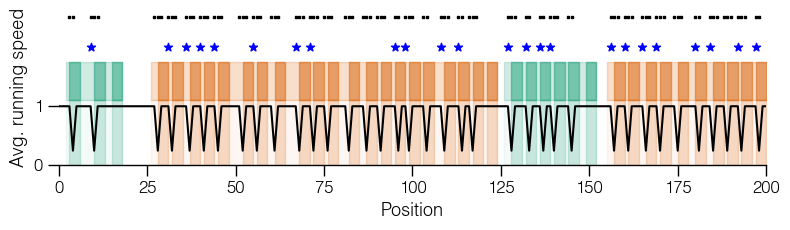

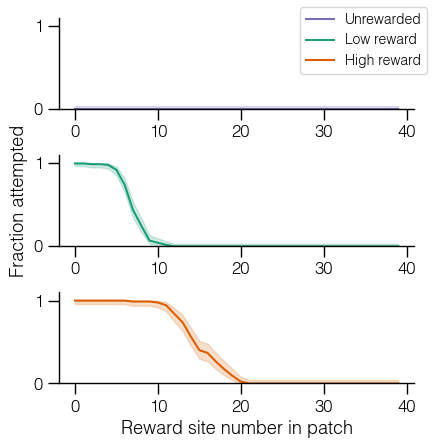

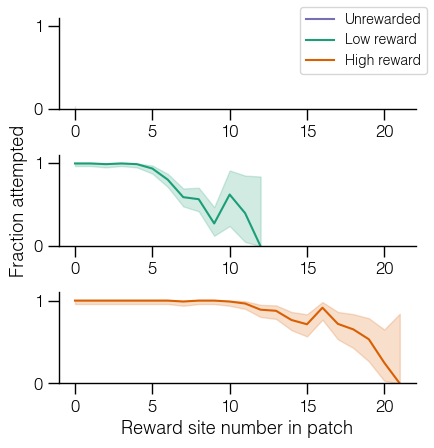

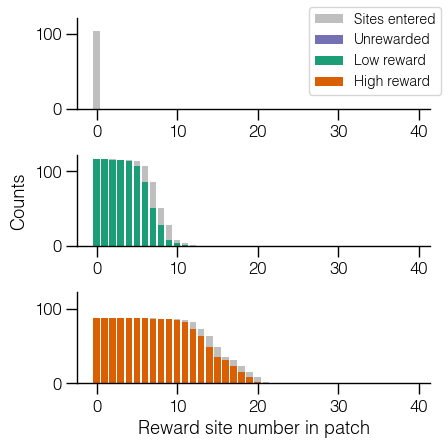

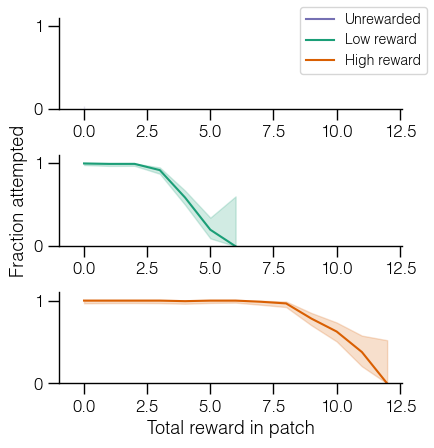

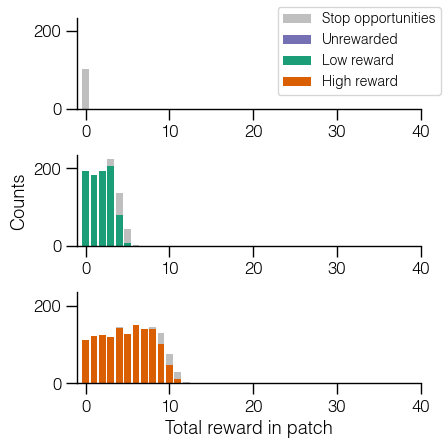

In [49]:
for i, data_path in enumerate(GRU_OFFSET_STRUCTURE_EVO_NETWORKS):
    plot_session(
        data_path,
        session_idx=0,
        xlim=(0, 200),
        max_reward_param=40,
        max_reward_sites=30,
        use_fixed_colors=True,
        color_by_reward_param=False,
    )

## Odor site data loading

In [35]:
session_indices = np.arange(0, 2000, 25)

In [36]:
network_paths = [
    os.path.join(GRU_OFFSET_STRUCTURE_EVO_NETWORKS_BASE, f'traj_{zero_pad(n, 6)}.pkl')
    for n in session_indices
]

dfs = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(network_paths)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated


/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:257: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['env_quality'] = np.sum(np.unique(df['patch_reward_param']))
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['index / reward_param'] = dfs['index'] / (dfs['patch_reward_param'] + 1e-6)
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:262: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries ge

/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:257: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['env_quality'] = np.sum(np.unique(df['patch_reward_param']))
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:261: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['index / reward_param'] = dfs['index'] / (dfs['patch_reward_param'] + 1e-6)
/home/david.bell/work/favorably_connected_2/code/behavioral_plotting.py:262: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries ge

## Mean rewards harvested and probability of reward at leave across sessions

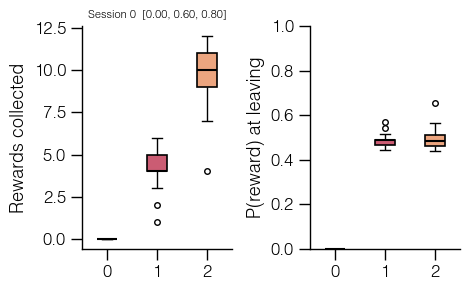

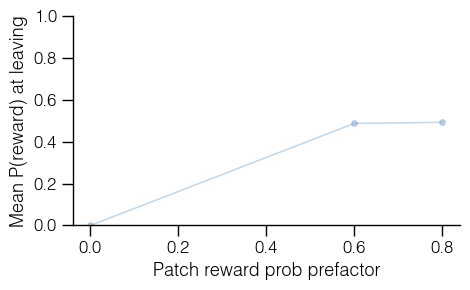

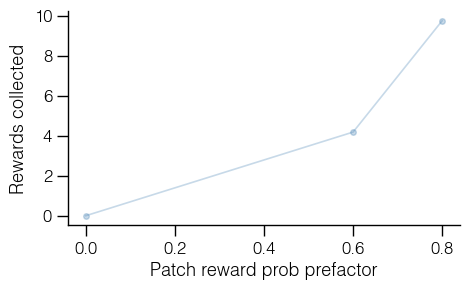

In [5]:
for df in dfs:
    plot_patch_statistics_per_session(
        df,
        ylim_right=[0, 1.],
    )

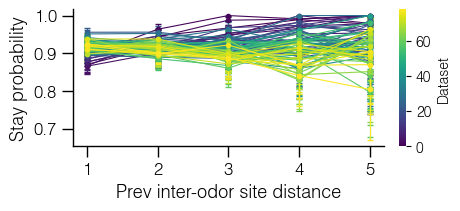

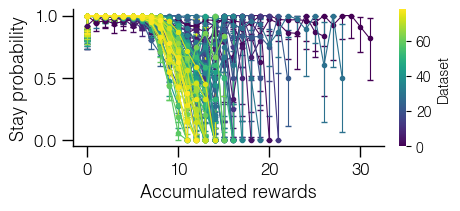

In [45]:
plot_leave_probabilities(
    [df[(df['index'] > 0) & (df['patch_type'] > 0)] for df in dfs[1:]],
    [
        'dist_last_odor_site',
    ],
    x_labels=[
        'Prev inter-odor site distance',
    ],
    cmap='viridis',
)

plot_leave_probabilities(
    [df[(df['index'] > 0) & (df['patch_type'] == 2)] for df in dfs[1:]],
    [
        'rewards_seen_in_patch',
    ],
    x_labels=[
        'Accumulated rewards',
    ],
    cmap='viridis',
)

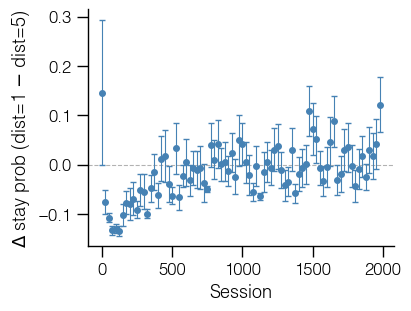

In [43]:
plot_stay_prob_distance_difference(
    [df[(df['index'] > 0) & (df['patch_type'] > 0)] for df in dfs],
    x_vals=session_indices,
)
None

Processing DF_0...


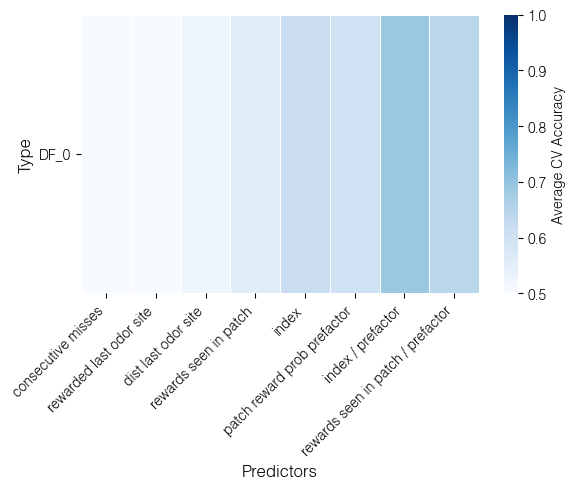

In [10]:
def gen_mask(df):
    return (df['index'] > 0) & (df['patch_type'] > 0)

plot_multi_df_accuracy_heatmap(
    [df[gen_mask(df)] for df in dfs],
    [
        'consecutive_misses',
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_prob_prefactor',
        'index / prefactor',
        'rewards_seen_in_patch / prefactor',
    ],
    # df_labels=['Randomized 499'] + [f'Fixed {s}' for s in np.arange(500, 600, 10)] + [f'Equal low {s}' for s in np.arange(600, 700, 10)],
    figsize=(6, 5),
)

## Accumulated reward against consecutive failures

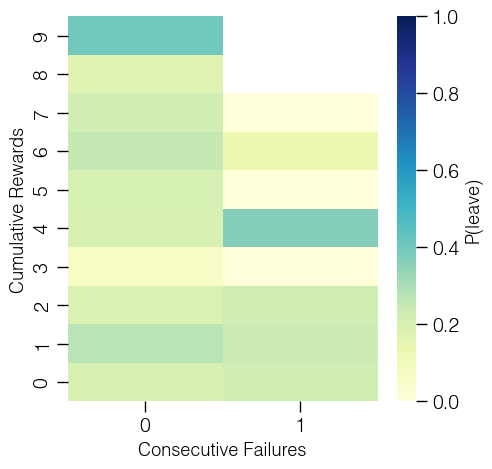

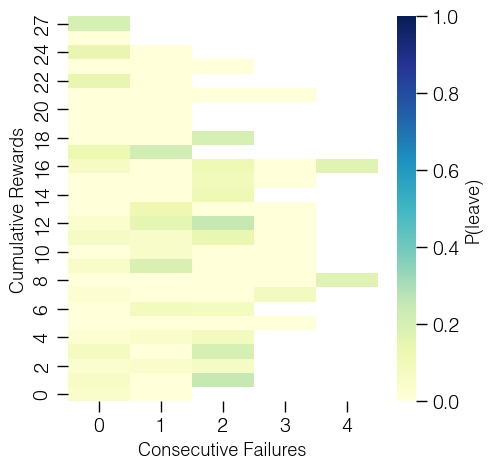

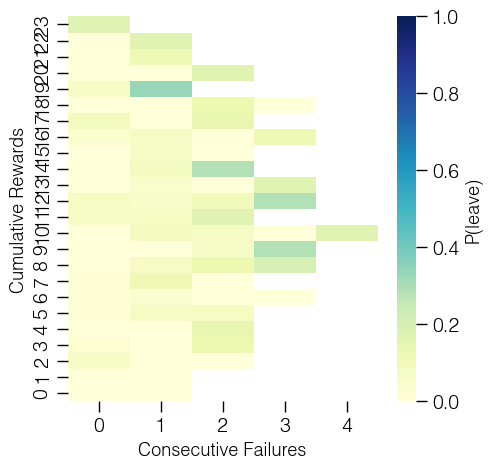

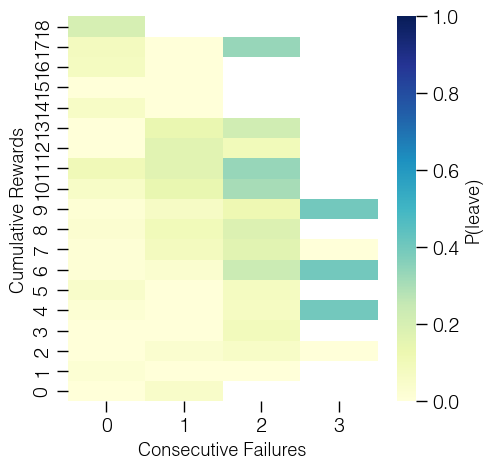

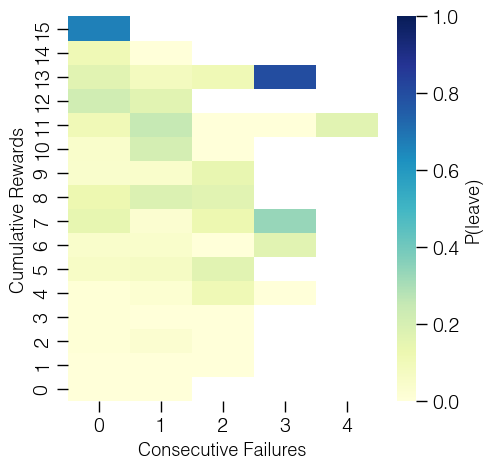

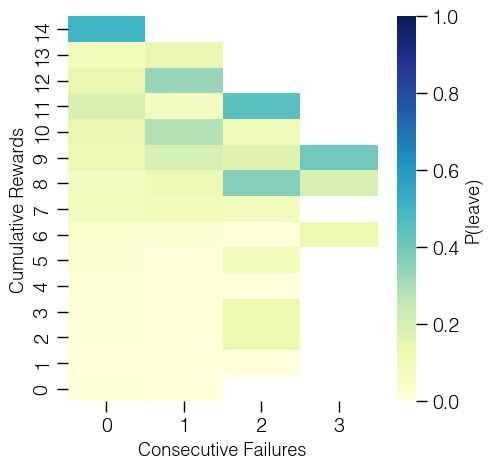

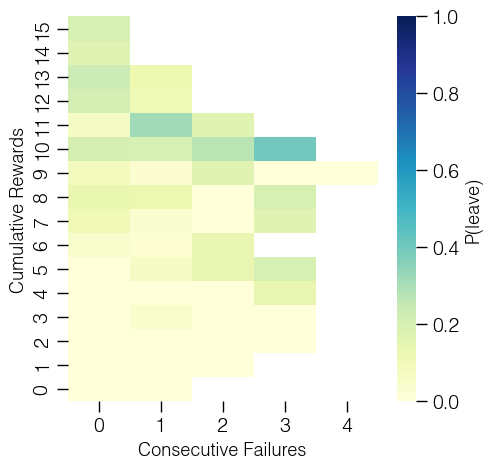

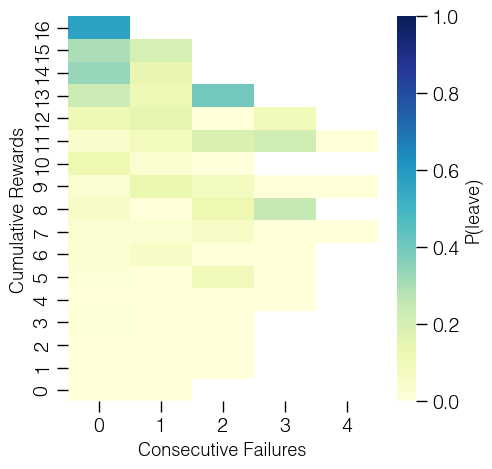

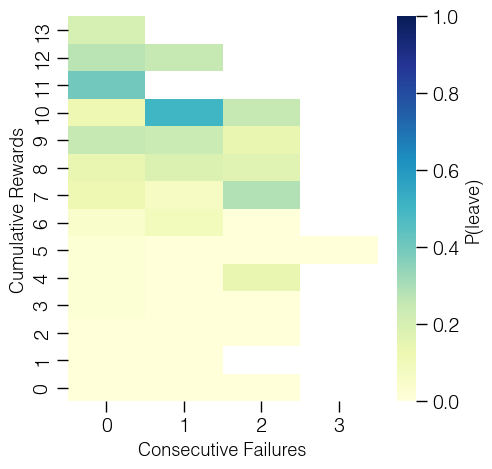

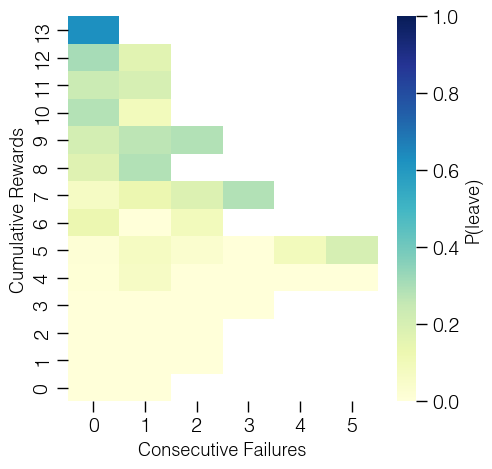

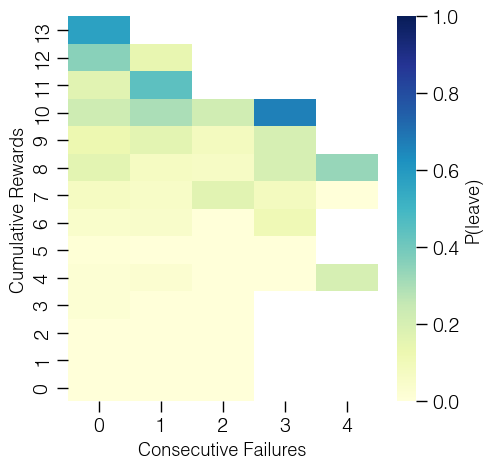

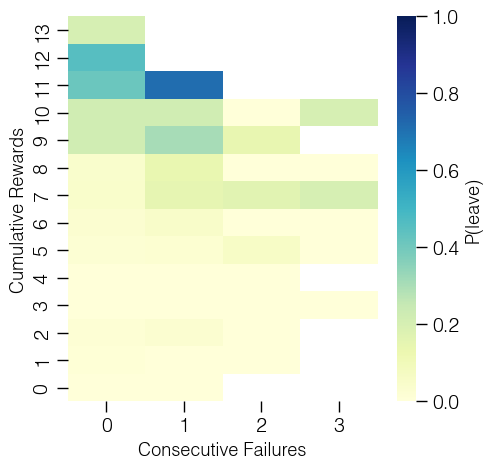

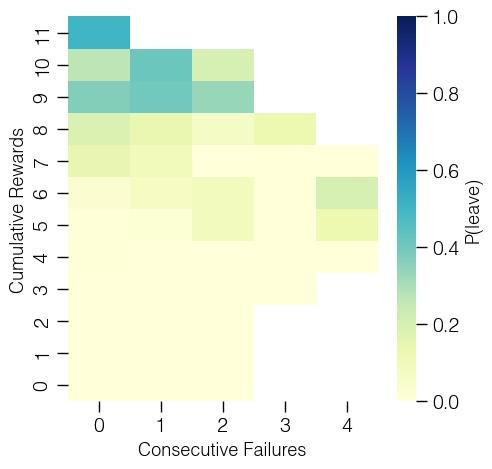

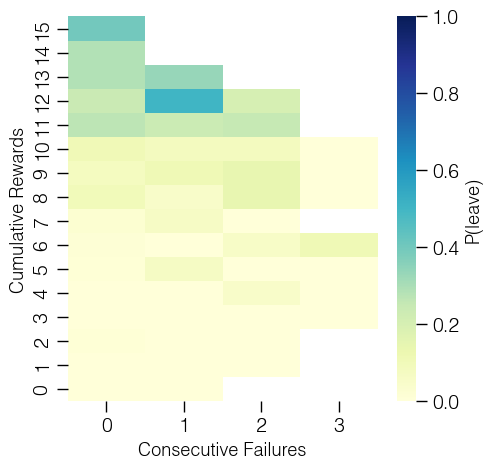

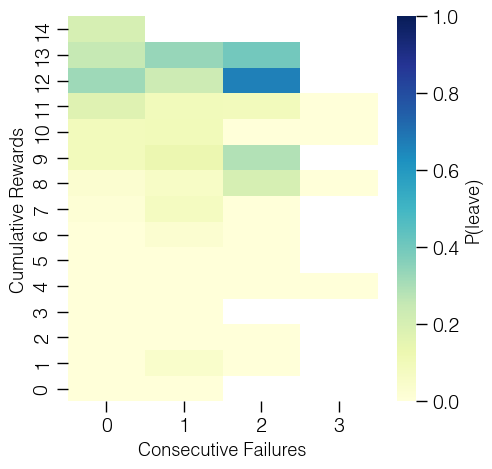

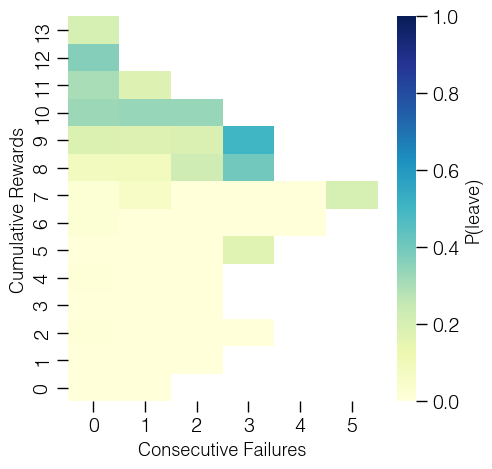

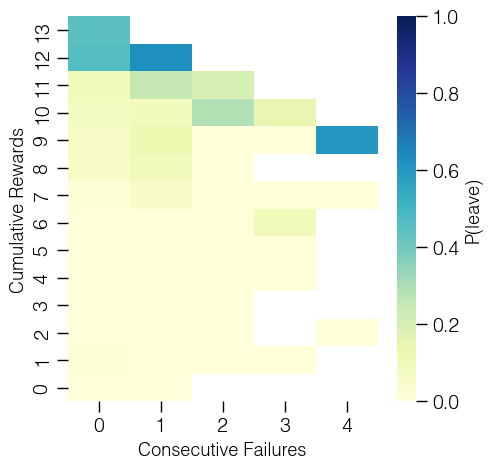

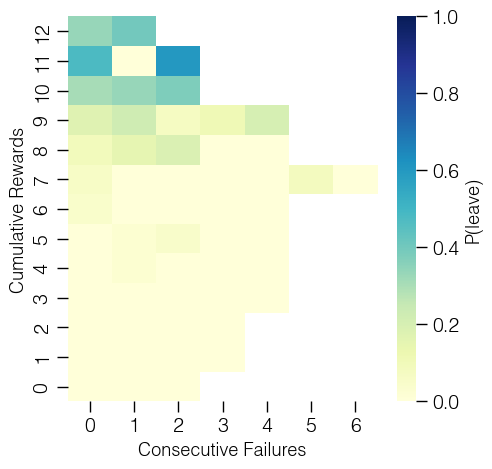

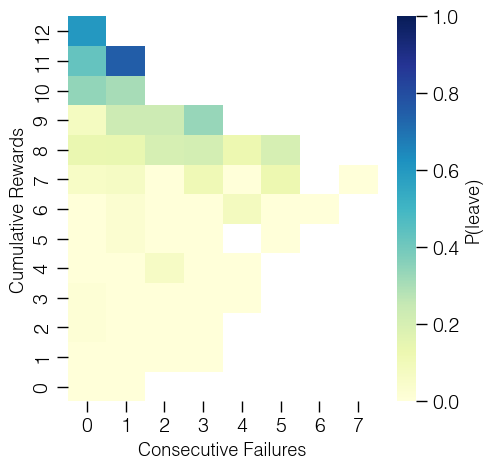

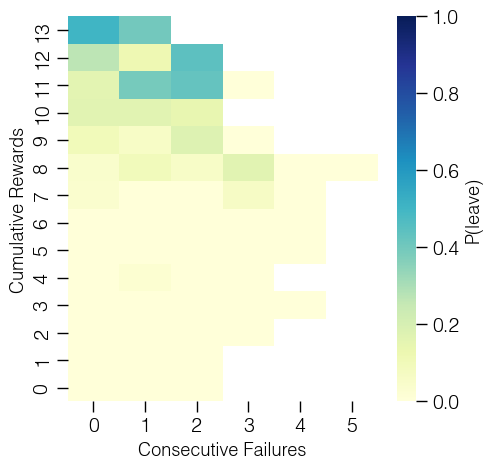

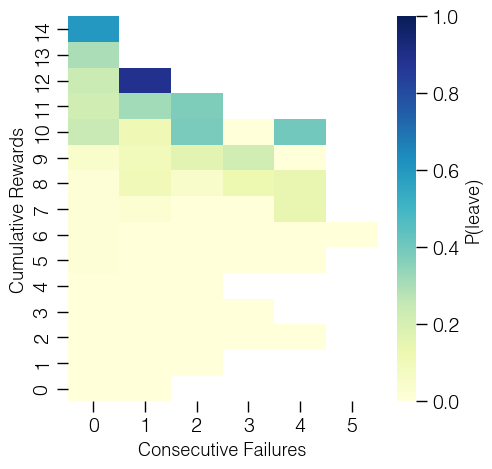

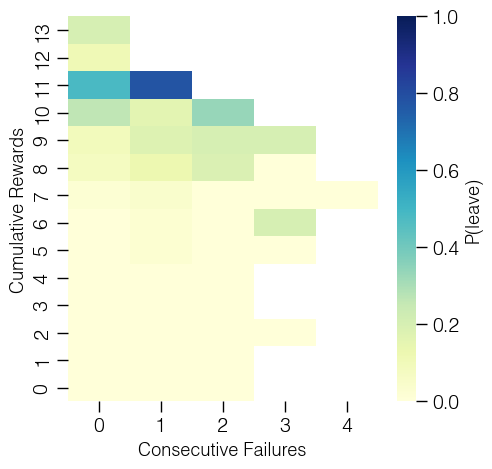

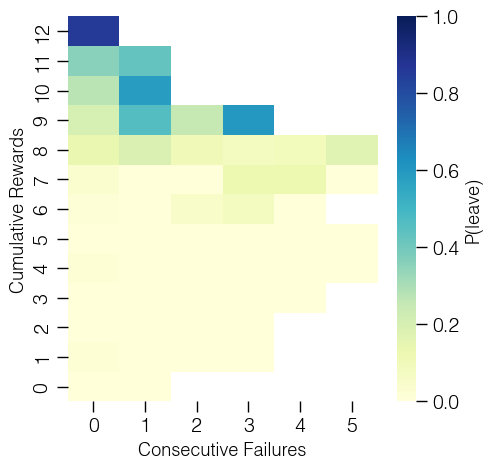

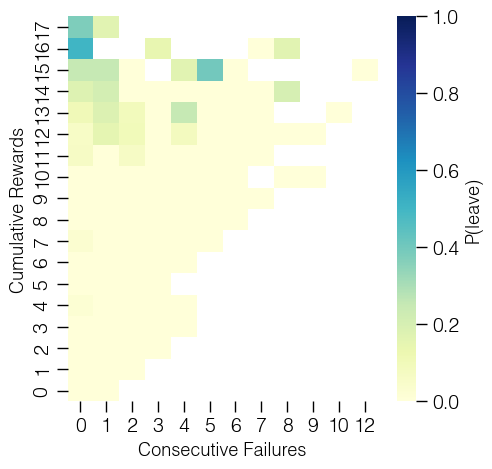

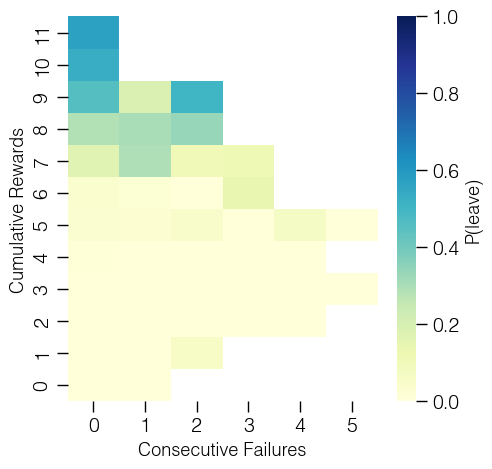

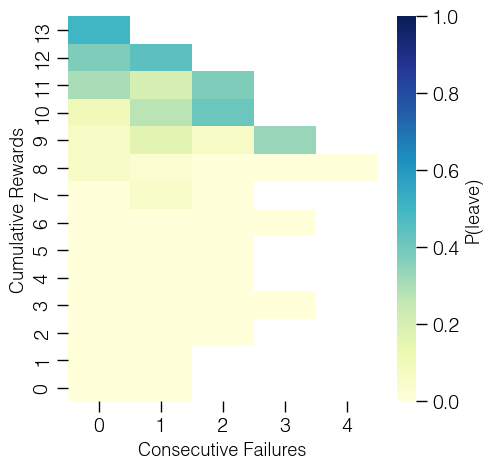

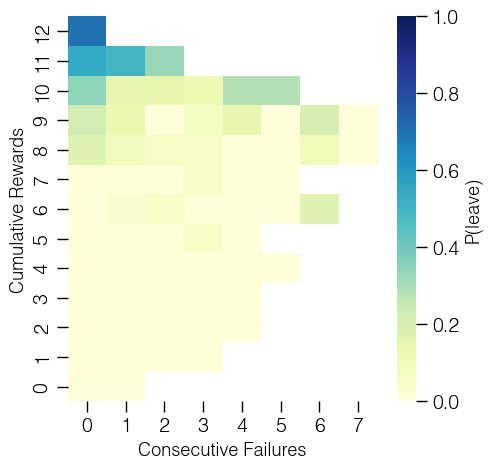

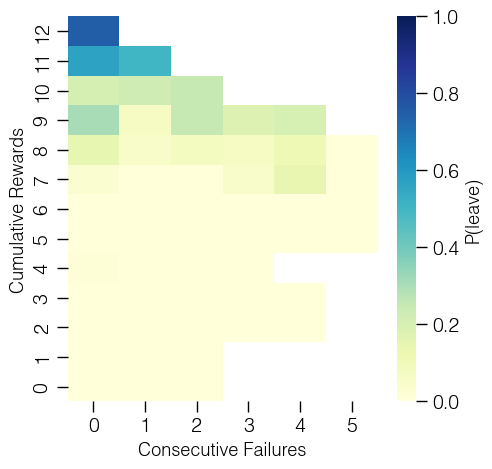

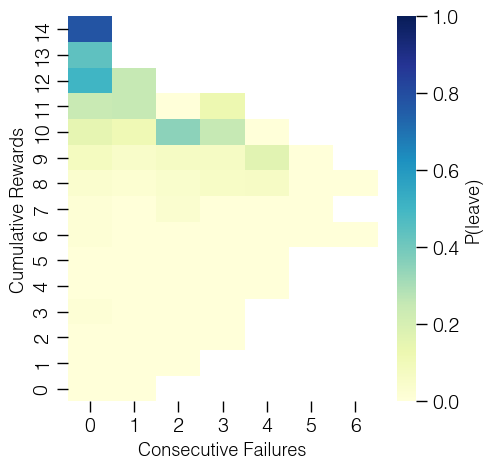

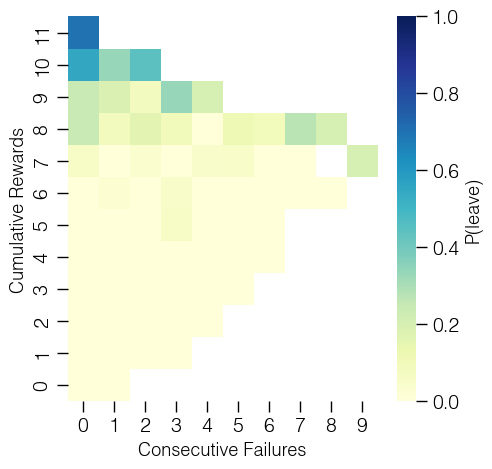

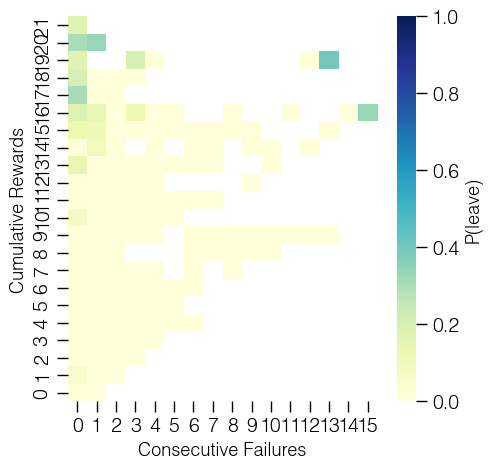

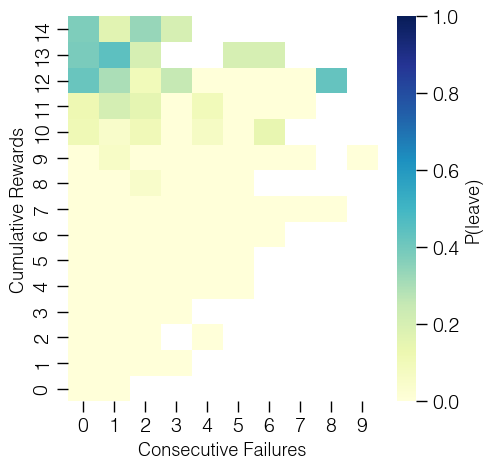

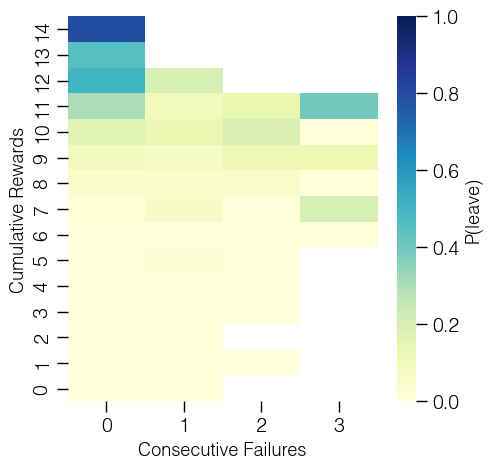

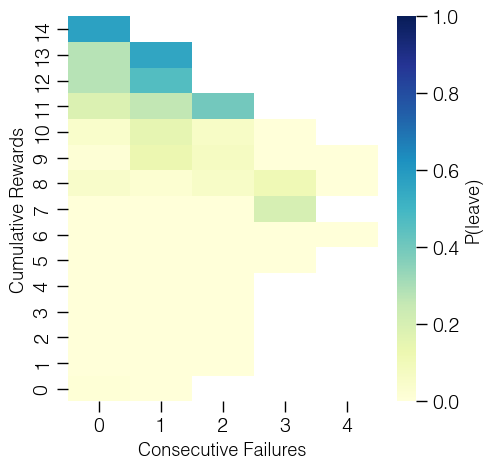

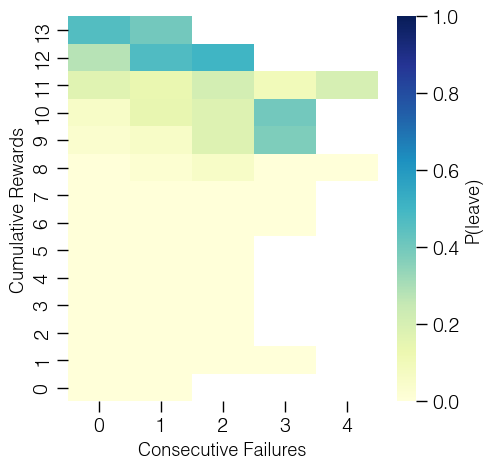

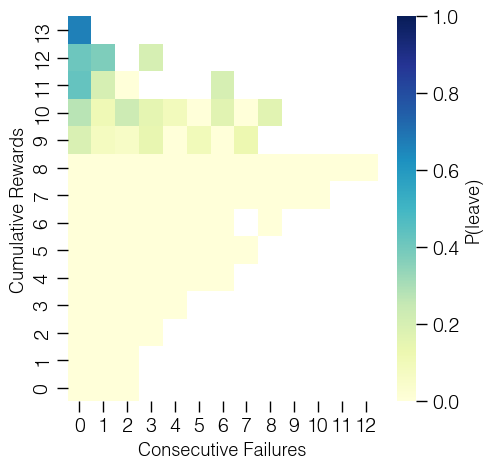

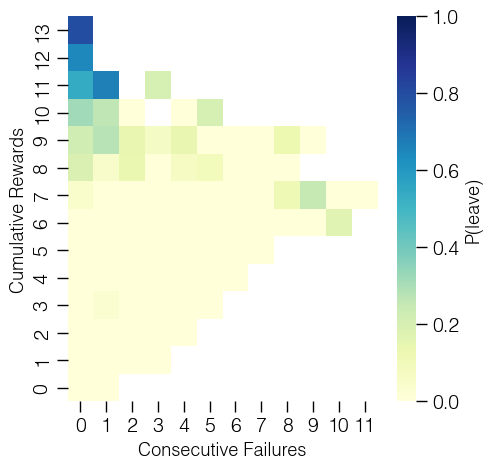

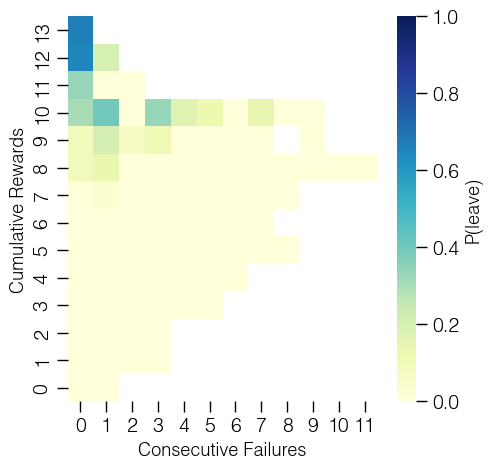

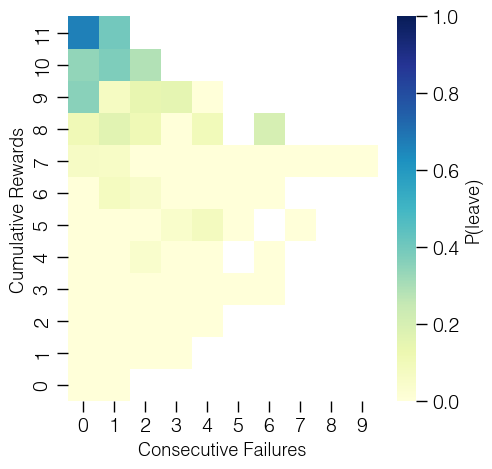

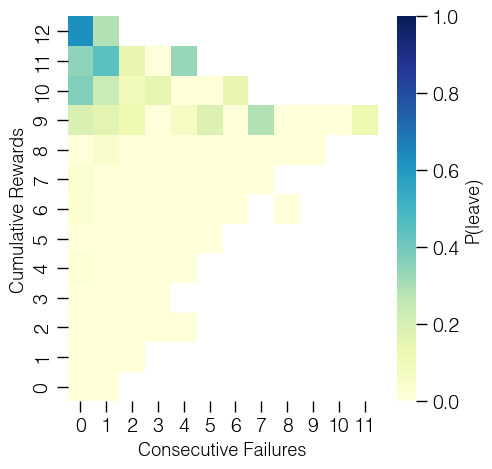

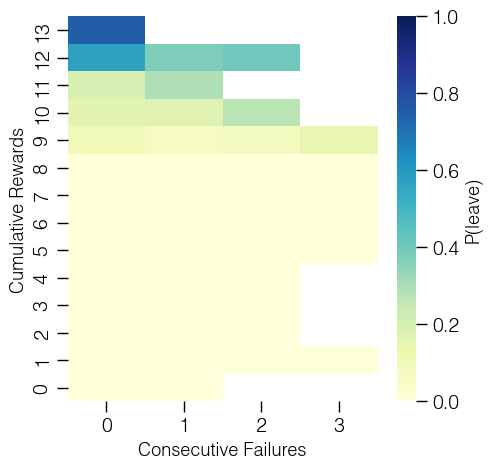

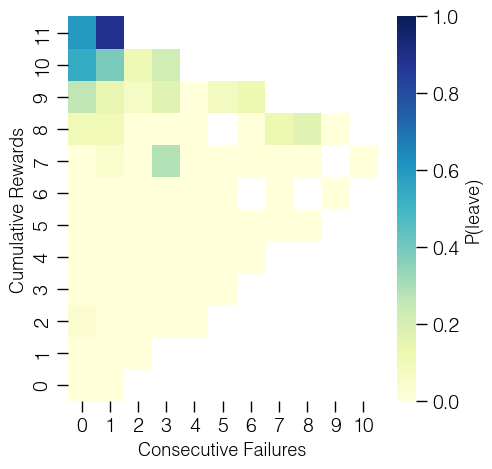

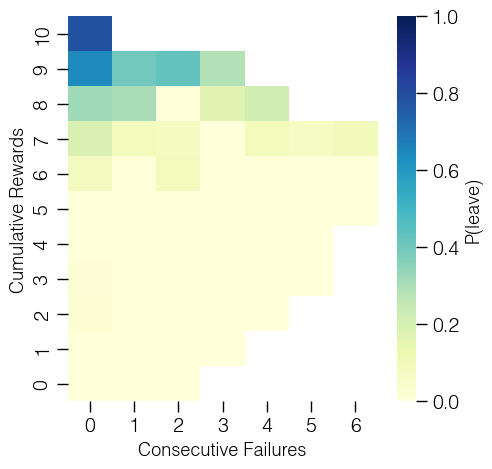

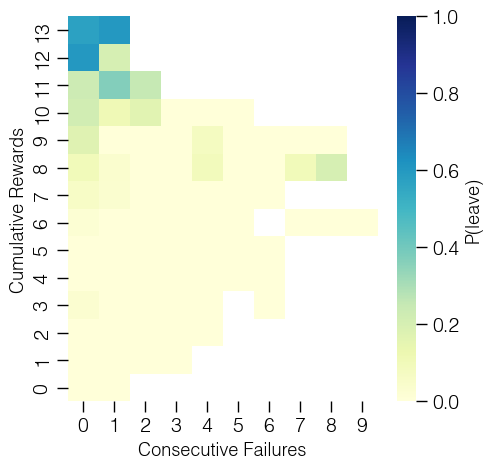

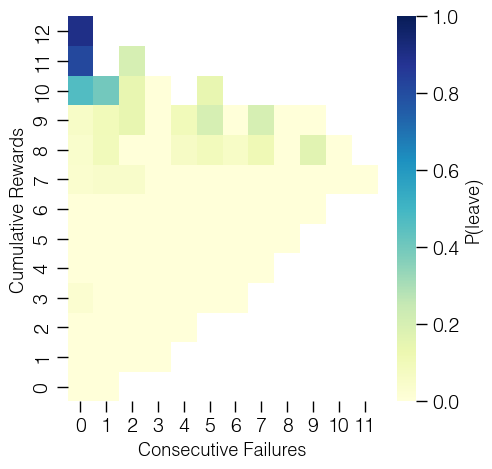

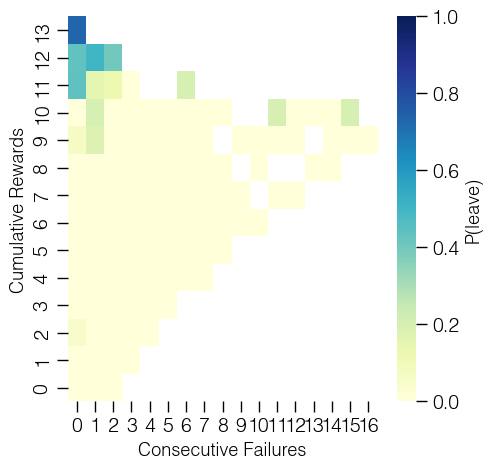

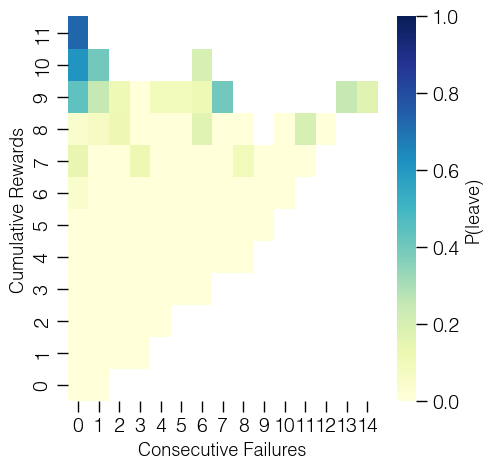

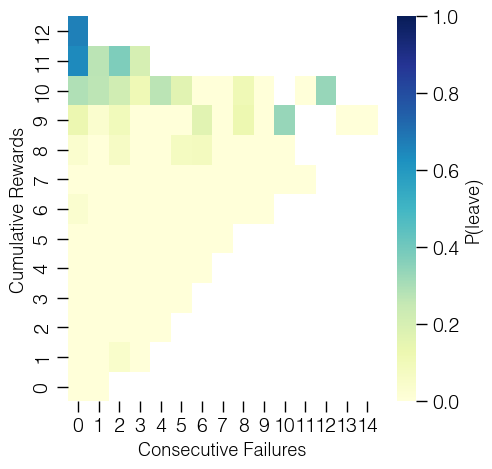

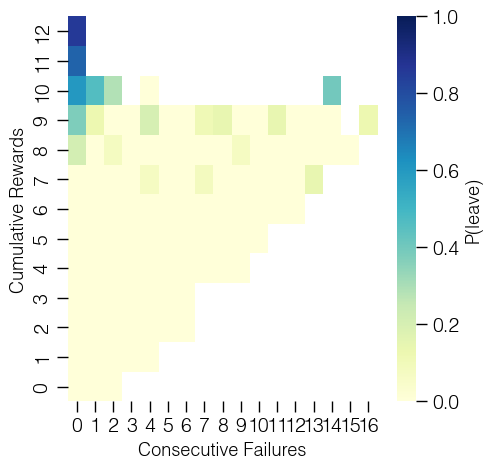

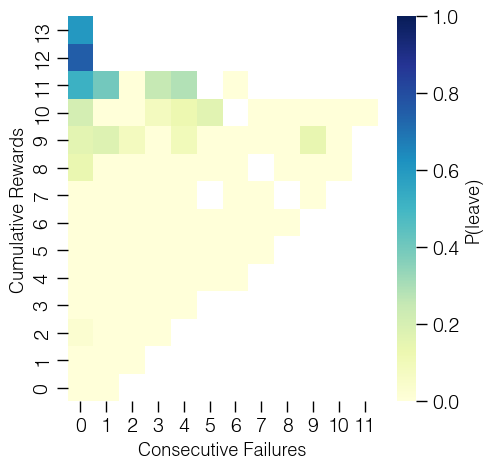

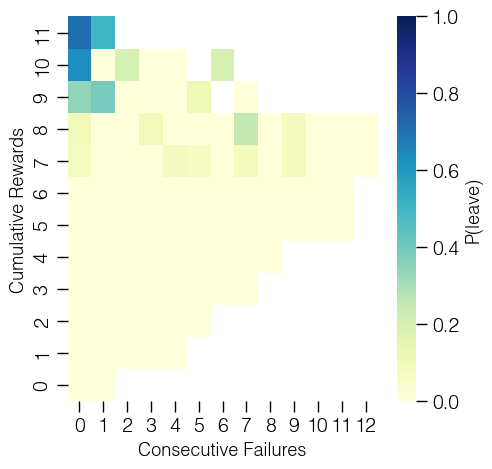

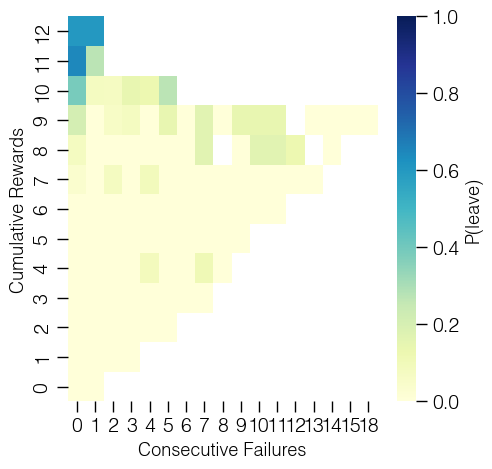

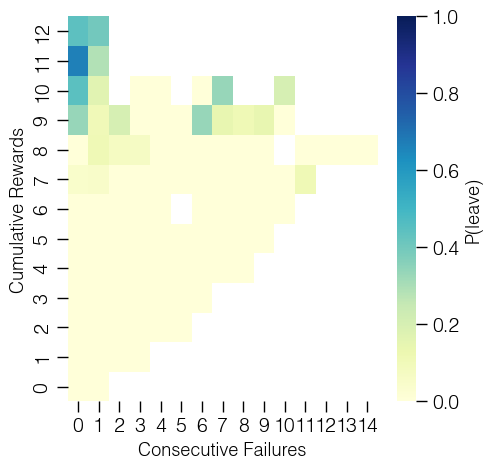

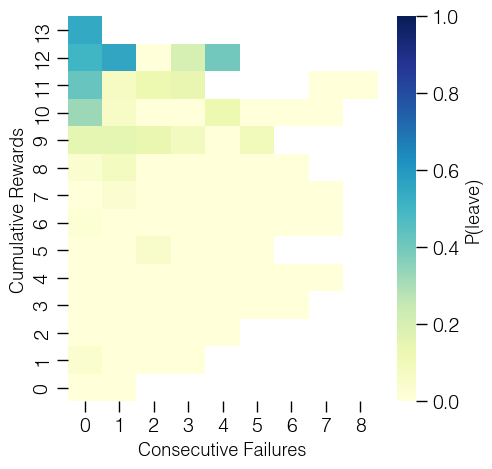

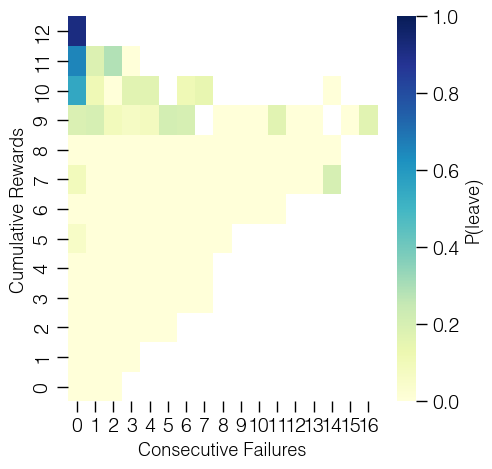

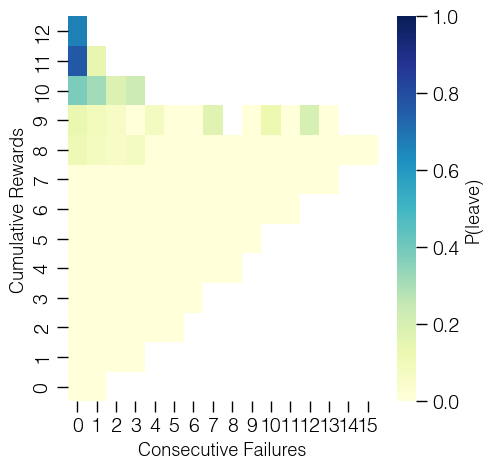

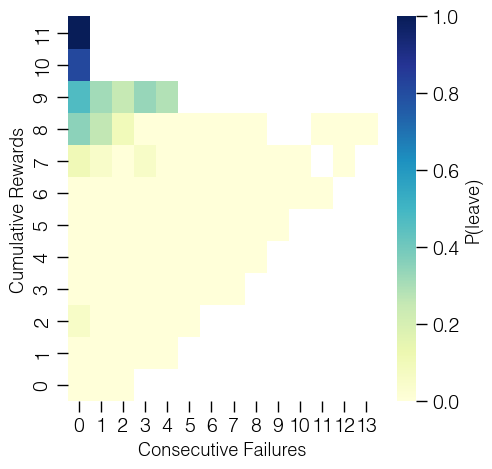

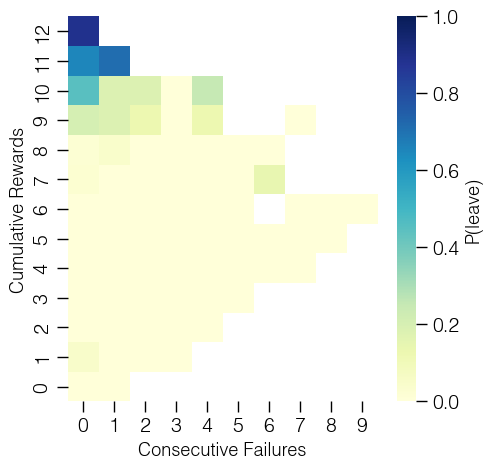

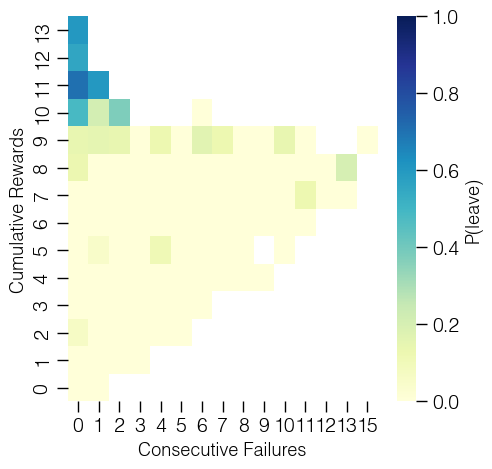

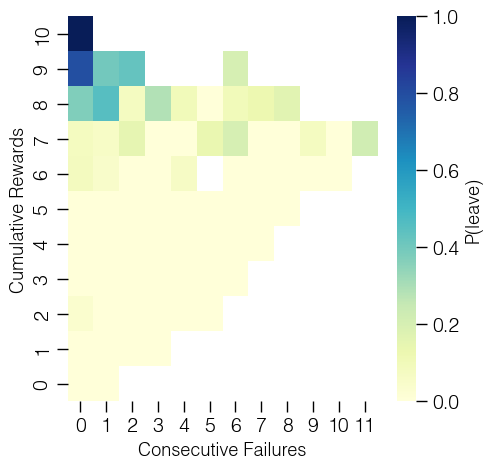

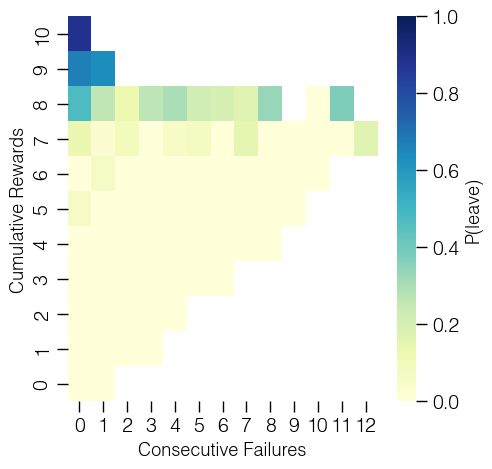

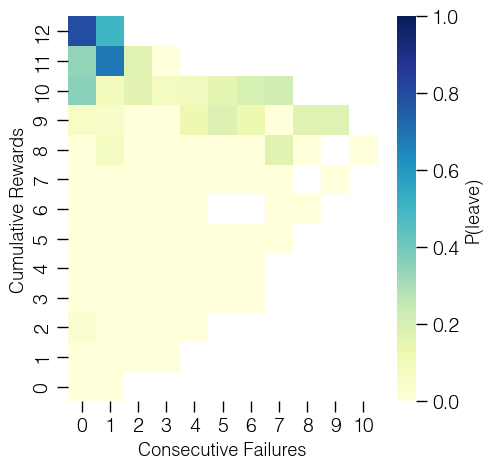

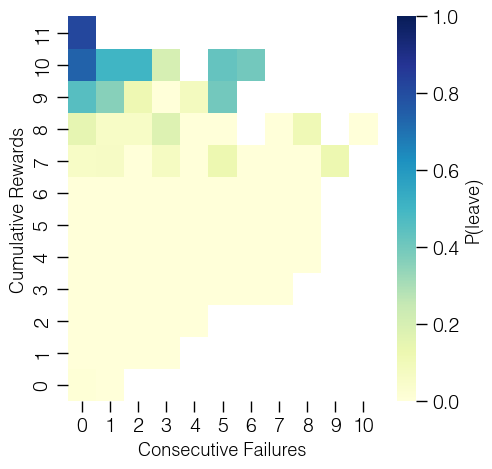

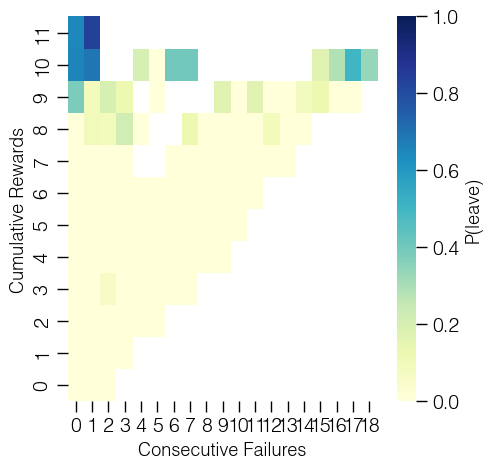

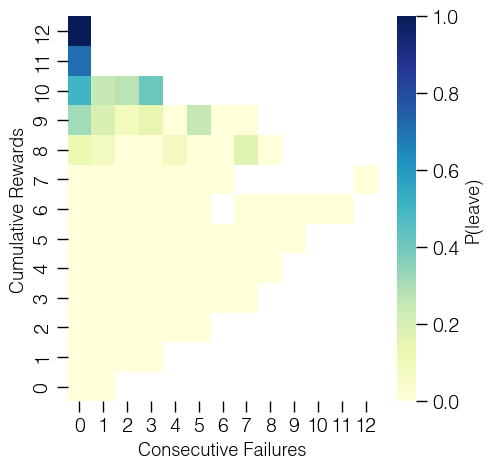

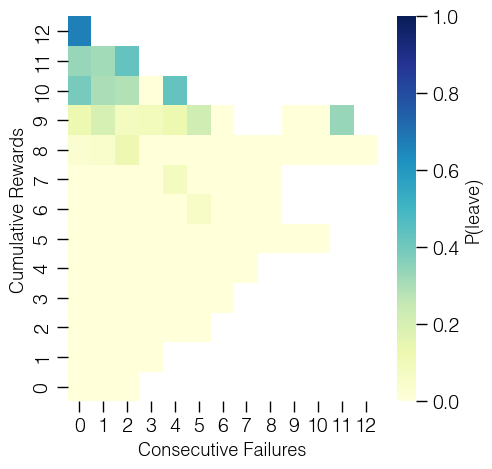

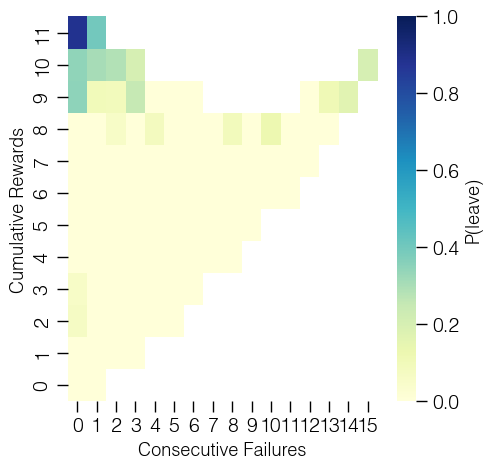

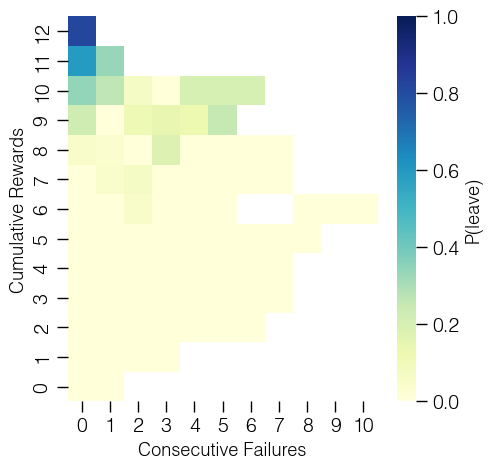

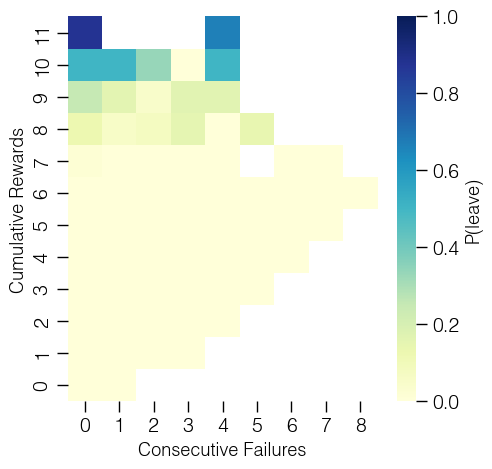

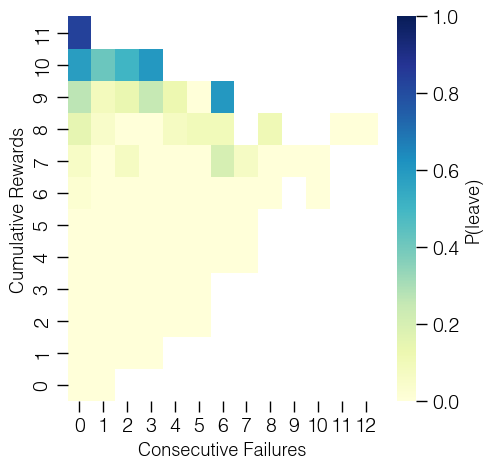

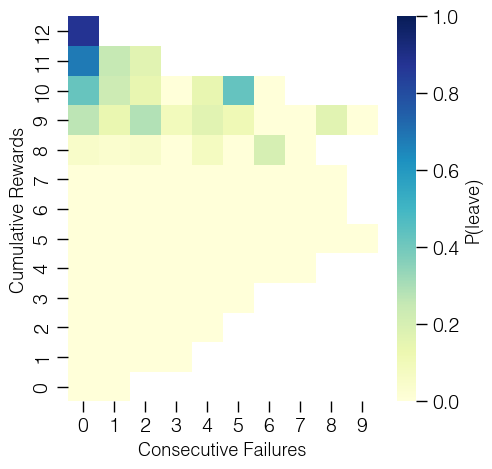

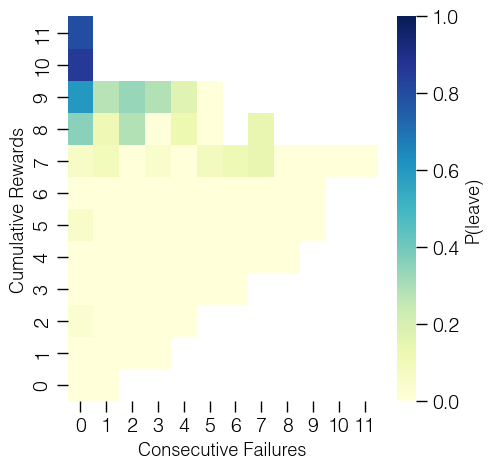

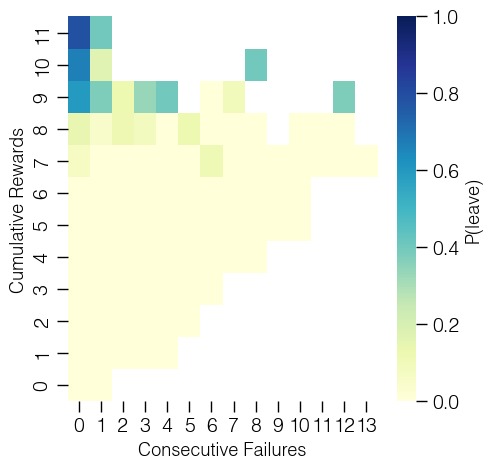

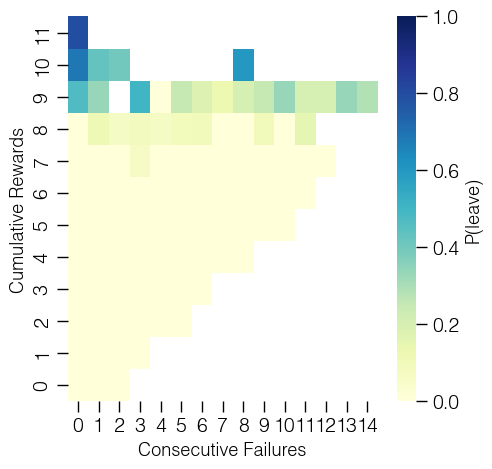

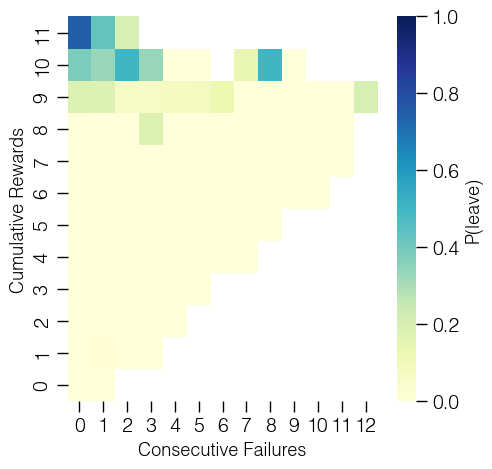

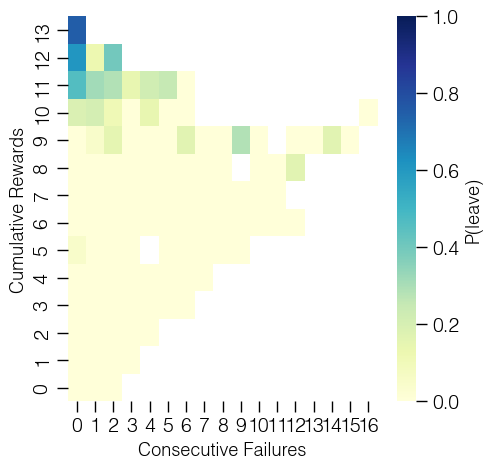

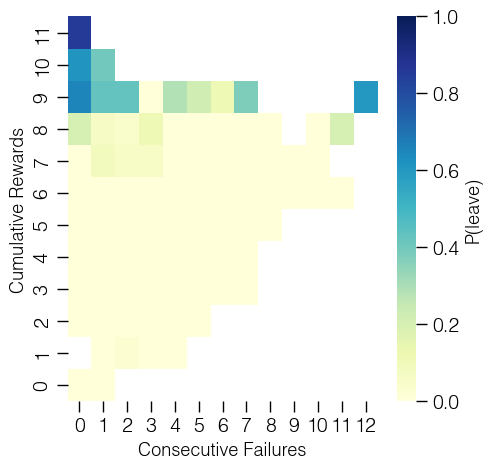

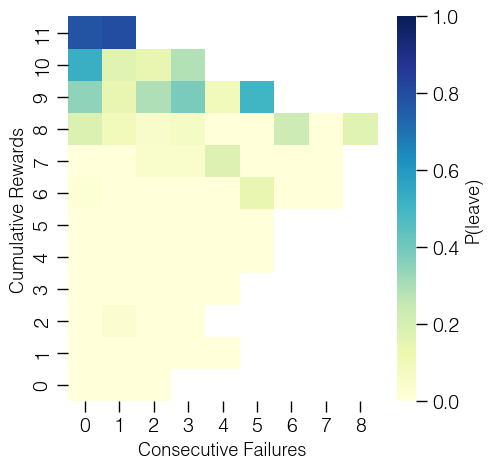

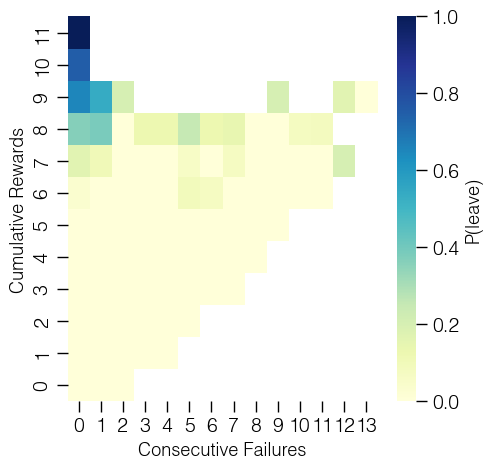

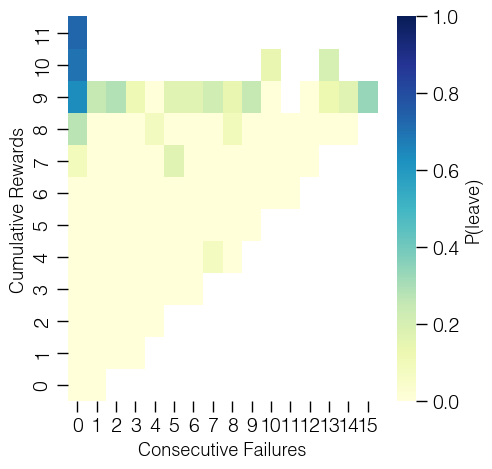

In [48]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 2],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=5,
    )
None